# Demo — Adapting TissueTypist to lung tissue (LOSO accuracy)

This notebook adapts TissueTypist to a **non-cardiac**
dataset: human lung Visium SD 3′ from
[Madissoon et al., 2023](https://doi.org/10.1038/s41588-022-01243-4).

**Setup:**

- Single modality (Visium SD 3′)
- Flat label column (`tissue_label`) → `--flat --coarse_col tissue_label`,
  no sub-models, no YAML.
- `obs["sample"]` is the section identifier


## 1. Setup

In [1]:
# Edit these paths if your local layout differs.
from pathlib import Path

REPO       = Path.home() / "GitHub" / "TissueTypist"
LUNG_QUERY = Path.home() / "GitHub" / "anndata" / "Madissoon2023_lung_visium_preprocessed.h5ad"

LOSO_OUTDIR = REPO / "results" / "lung_loso_demo"      # per-fold cache + pooled outputs
LOSO_OUTDIR.mkdir(parents=True, exist_ok=True)

assert LUNG_QUERY.exists(), f"Missing input: {LUNG_QUERY}"


In [10]:
import json, subprocess, warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import tissuetypist
from tissuetypist import predict_adata
print("TissueTypist:", getattr(tissuetypist, "__version__", "(dev install)"))

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

TissueTypist: 2.0.0-dev


In [7]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

import seaborn as sns
import matplotlib.pyplot as plt

In [112]:
figdir = '/Users/kazumasakanemaru/Data_kk/Foetal_ms_raw_plots_from-mac'

## 2. Inspect the lung dataset

Loading once. The remaining cells reuse this `adata` — no re-reads.


In [3]:
adata = sc.read_h5ad(LUNG_QUERY)

# TissueTypist's training code reads `obs["section_ID"]` directly. Copy
# `sample` over so we don't have to fork the upstream code path.
adata.obs["section_ID"] = adata.obs["sample"].astype(str)

print(adata)
print()
print("Tissue labels:", adata.obs["tissue_label"].nunique())
print("Sections     :", adata.obs["section_ID"].nunique())


AnnData object with n_obs × n_vars = 13306 × 12912
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'Perichondrium', 'Weird_morphology', 'Cartilage', 'Glands', 'Tissue', 'Multilayer_epithelium', 'Nerve', 'Venous_vessel', 'Airway_Smooth_Muscle', 'Arterial_vessel', 'Parenchyma', 'Pulmonary_vessel', 'Mesothelium', 'Small_airway', 'iBALT', '_indices', '_scvi_batch', '_scvi_labels', 'tissue_label', 'section_ID'
    var: 'feature_types', 'genome', 'SYMBOL', 'mt', 'n_cells_by_counts-WSA_LngSP10193345', 'mean_counts-WSA_LngSP10193345', 'log1p_mean_counts-WSA_LngSP10193345', 'pct_dropout_by_counts-WSA_LngSP10193345', 'total_counts-WSA_LngSP10193345', 'log1p_total_counts-WSA_LngSP10193345', 'n_cells_by_counts-WSA_LngSP10193346', 'mean_counts-WSA_LngSP10193346', 'log1p_me

In [4]:
# How many spots per tissue label?
adata.obs["tissue_label"].value_counts()


tissue_label
Parenchyma               6799
Cartilage                1863
Multilayer_epithelium    1084
Glands                    993
Perichondrium             956
Airway_Smooth_Muscle      541
Pulmonary_vessel          450
Mesothelium               324
Arterial_vessel           117
Small_airway              105
Nerve                      58
Venous_vessel              16
Name: count, dtype: int64

In [5]:
# How are labels distributed across sections? Useful for spotting
# rare-class folds before kicking off the loop.
xtab = pd.crosstab(adata.obs["tissue_label"], adata.obs["section_ID"])
xtab


section_ID,WSA_LngSP10193345,WSA_LngSP10193346,WSA_LngSP10193347,WSA_LngSP10193348,WSA_LngSP8759311,WSA_LngSP8759312,WSA_LngSP8759313,WSA_LngSP9258463,WSA_LngSP9258464,WSA_LngSP9258467,WSA_LngSP9258468
tissue_label,,,,,,,,,,,
Airway_Smooth_Muscle,0,0,0,56,132,146,29,5,86,11,76
Arterial_vessel,0,0,0,0,29,35,22,10,0,10,11
Cartilage,0,0,0,123,408,437,570,10,181,7,127
Glands,0,0,0,81,145,148,88,5,253,10,263
Mesothelium,0,263,61,0,0,0,0,0,0,0,0
Multilayer_epithelium,0,0,0,70,117,130,152,74,227,79,235
Nerve,0,0,0,0,22,20,4,1,1,8,2
Parenchyma,2997,1837,1721,140,0,0,0,47,0,57,0
Perichondrium,0,0,0,89,133,147,142,31,170,47,197


In [75]:
palette = sns.color_palette("tab20", n_colors=adata.obs["tissue_label"].nunique())
label_to_colour = dict(zip(sorted(adata.obs["tissue_label"].unique()), palette))

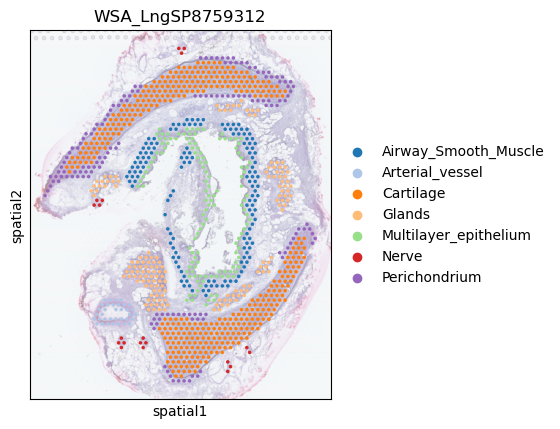

In [76]:
# Quick spatial preview of a single section.
section = 'WSA_LngSP8759312'
slide = select_slide(adata, s=section, s_col='section_ID')
sc.pl.spatial(slide, color='tissue_label', alpha_img=0.5, 
              palette=label_to_colour, title=section)

## 3. Leave-one-section-out (LOSO) validation

11 lung sections, each held out in turn, so the model is always asked to generalise to
*sample geometry it has never seen*.

For every fold we:

1. Subset `adata` to the 10 training sections, write a temp h5ad.
2. Run `tissuetypist train --flat` on it (own_only weights — fast).
3. Run `predict_adata` on the held-out section.
4. Score predictions against `tissue_label` (weighted + macro F1).
5. Cache predictions and metrics under `LOSO_OUTDIR / per_fold / <section>/`.

The cache makes the loop **resumable** — if the kernel crashes mid-loop,
re-running picks up where it left off.


## 4. One fold, step by step

Walk through a single fold first so you can see what each step
produces. The full loop in §5 is the same code wrapped in a `for`.


In [14]:
def train_one_fold(adata, held_out_section, out_root):
    # Train on all sections != held_out_section. Returns model_dir path.
    fold_dir = Path(out_root) / "per_fold" / f"{held_out_section}"
    model_dir = fold_dir / "model"
    if (model_dir / "hierarchy_config.json").exists():
        return model_dir   # already trained

    fold_dir.mkdir(parents=True, exist_ok=True)
    train_mask = adata.obs["section_ID"] != held_out_section
    train_adata = adata[train_mask].copy()

    train_path = fold_dir / "train_subset.h5ad"
    train_adata.write_h5ad(train_path)

    cmd = [
        "tissuetypist", "train",
        "--reference",       str(train_path),
        "--outdir",          str(model_dir),
        "--flat",            "--coarse_col", "tissue_label",
        "--neighbour_weight", "0.3",
        "--edge_weight",      "5",
    ]
    print("$ " + " ".join(cmd))
    subprocess.run(cmd, check=True)

    train_path.unlink()    # don't leave 200+ MB temp files lying around
    return model_dir


Held out: WSA_LngSP8759312
Model dir: /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP8759312/model
Held-out section: WSA_LngSP8759312  (n_spots = 1,063)
  F1 weighted: 0.778
  F1 macro   : 0.774

                       precision    recall  f1-score   support

 Airway_Smooth_Muscle       0.77      0.72      0.74       146
      Arterial_vessel       1.00      0.91      0.96        35
            Cartilage       0.77      0.94      0.85       437
               Glands       0.93      0.82      0.87       148
Multilayer_epithelium       0.76      0.69      0.73       130
                Nerve       1.00      0.60      0.75        20
        Perichondrium       0.62      0.45      0.52       147

             accuracy                           0.79      1063
            macro avg       0.84      0.73      0.77      1063
         weighted avg       0.78      0.79      0.78      1063



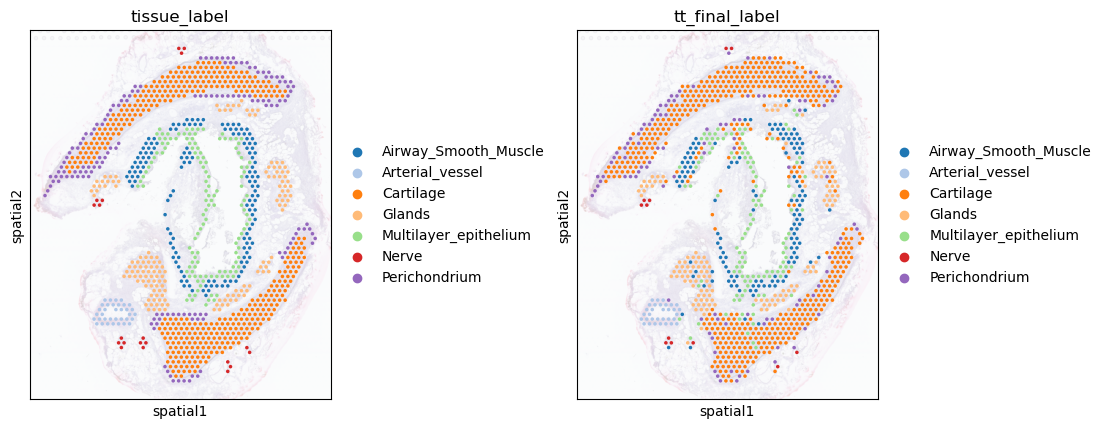

In [113]:
# Pick the first section as the demo fold.
demo_section = 'WSA_LngSP8759312'
print(f"Held out: {demo_section}")

demo_model_dir = train_one_fold(adata, demo_section, LOSO_OUTDIR)
print("Model dir:", demo_model_dir)

# Predict on the held-out section.
test_adata = select_slide(adata, s=demo_section, s_col='section_ID')

test_adata = predict_adata(
    test_adata,
    model_dir   = str(demo_model_dir),
    modality    = "sd",
    section_col = "section_ID",
)

from sklearn.metrics import f1_score, classification_report
y_true = test_adata.obs["tissue_label"].astype(str)
y_pred = test_adata.obs["tt_final_label"].astype(str)

print(f"Held-out section: {demo_section}  (n_spots = {len(y_true):,})")
print(f"  F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.3f}")
print(f"  F1 macro   : {f1_score(y_true, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

# ground truth: 'tissue_label'
# TT prediction: 'tt_final_label'
sc.pl.spatial(test_adata, 
              color=['tissue_label','tt_final_label'], wspace=0.05,
              alpha_img=0.2,  palette=label_to_colour, show=False)
plt.savefig(f'{figdir}/TissueTypist_Lung-VisiumSD_{demo_section}.pdf', bbox_inches="tight",dpi=300)

Held out: WSA_LngSP9258464
Model dir: /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP9258464/model
Held-out section: WSA_LngSP9258464  (n_spots = 918)
  F1 weighted: 0.774
  F1 macro   : 0.469

                       precision    recall  f1-score   support

 Airway_Smooth_Muscle       0.67      0.67      0.67        86
      Arterial_vessel       0.00      0.00      0.00         0
            Cartilage       0.82      0.59      0.69       181
               Glands       0.81      0.93      0.87       253
Multilayer_epithelium       0.87      0.86      0.86       227
                Nerve       0.00      0.00      0.00         1
           Parenchyma       0.00      0.00      0.00         0
        Perichondrium       0.64      0.69      0.67       170

             accuracy                           0.78       918
            macro avg       0.48      0.47      0.47       918
         weighted avg       0.78      0.78      0.77       918



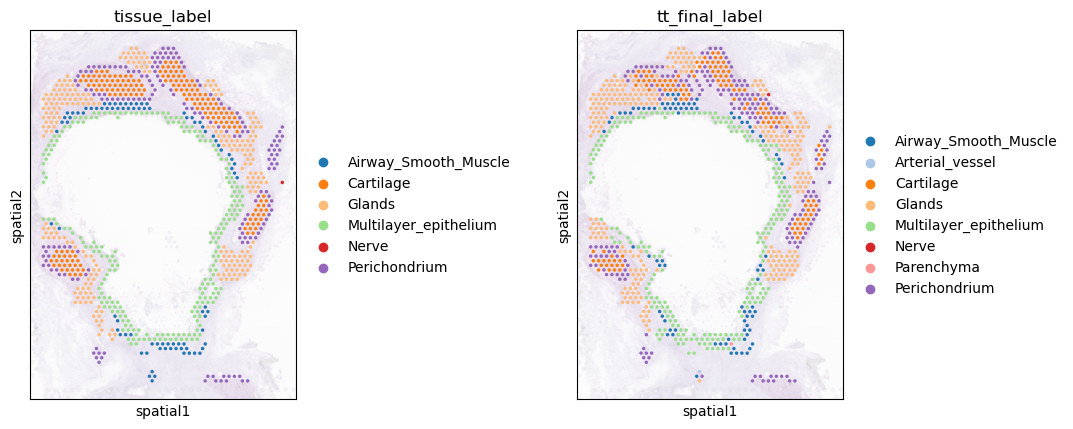

In [114]:
# Pick the first section as the demo fold.
demo_section = 'WSA_LngSP9258464'
print(f"Held out: {demo_section}")

demo_model_dir = train_one_fold(adata, demo_section, LOSO_OUTDIR)
print("Model dir:", demo_model_dir)

# Predict on the held-out section.
test_adata = select_slide(adata, s=demo_section, s_col='section_ID')

test_adata = predict_adata(
    test_adata,
    model_dir   = str(demo_model_dir),
    modality    = "sd",
    section_col = "section_ID",
)

from sklearn.metrics import f1_score, classification_report
y_true = test_adata.obs["tissue_label"].astype(str)
y_pred = test_adata.obs["tt_final_label"].astype(str)

print(f"Held-out section: {demo_section}  (n_spots = {len(y_true):,})")
print(f"  F1 weighted: {f1_score(y_true, y_pred, average='weighted'):.3f}")
print(f"  F1 macro   : {f1_score(y_true, y_pred, average='macro'):.3f}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

# ground truth: 'tissue_label'
# TT prediction: 'tt_final_label'
sc.pl.spatial(test_adata, 
              color=['tissue_label','tt_final_label'], wspace=0.05,
              alpha_img=0.2,  palette=label_to_colour, show=False)
plt.savefig(f'{figdir}/TissueTypist_Lung-VisiumSD_{demo_section}.pdf', bbox_inches="tight",dpi=300)

## 5. Full 11-fold loop

Per-fold caching: each fold writes `predicted.h5ad` + `metrics.json`
under `per_fold/<section>/`, and on re-run we skip any fold that already
has both files. So if you Ctrl+C halfway through, the next run finishes
the rest.


In [50]:
def _sanitise_obs_for_h5ad(adata):
    # Flat hierarchies leave `tt_fine_label` / `tt_fine_score` / `tt_joint_score`
    # all-None — h5ad's vlen-string writer can't serialise that. Drop fully-null
    # tt_* columns and cast partially-filled object columns to str. This is
    # purely a write-time fix; the predictions themselves are fine in memory.
    for col in list(adata.obs.columns):
        s = adata.obs[col]
        if s.dtype != object:
            continue
        if s.isna().all():
            del adata.obs[col]
        else:
            adata.obs[col] = s.fillna("").astype(str)
    return adata


def run_one_fold(adata, held_out_section, out_root):
    # Train + predict + score one fold. Idempotent (uses cache).
    fold_dir = Path(out_root) / "per_fold" / f"{held_out_section}"
    pred_path = fold_dir / "predicted.h5ad"
    metrics_path = fold_dir / "metrics.json"

    if pred_path.exists() and metrics_path.exists():
        return json.loads(metrics_path.read_text())

    model_dir = train_one_fold(adata, held_out_section, out_root)

    test_adata = adata[adata.obs["section_ID"] == held_out_section].copy()
    test_adata = predict_adata(
        test_adata, model_dir=str(model_dir),
        modality="sd", section_col="section_ID",
    )
    _sanitise_obs_for_h5ad(test_adata)
    test_adata.write_h5ad(pred_path)

    y_true = test_adata.obs["tissue_label"].astype(str)
    y_pred = test_adata.obs["tt_final_label"].astype(str)
    metrics = {
        "section":     str(held_out_section),
        "n_spots":     int(len(y_true)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted",
                                      zero_division=0)),
        "f1_macro":    float(f1_score(y_true, y_pred, average="macro",
                                      zero_division=0)),
    }
    metrics_path.write_text(json.dumps(metrics, indent=2))
    return metrics


In [51]:
sections = sorted(adata.obs["section_ID"].unique())
print(f"LOSO over {len(sections)} sections.")

all_metrics = []
for i, sec in enumerate(sections, 1):
    print(f"[{i:2d}/{len(sections)}] Held-out: {sec}")
    m = run_one_fold(adata, sec, LOSO_OUTDIR)
    print(f"           n={m['n_spots']:>5,}  "
          f"F1_w={m['f1_weighted']:.3f}  F1_m={m['f1_macro']:.3f}")
    all_metrics.append(m)


LOSO over 11 sections.
[ 1/11] Held-out: WSA_LngSP10193345
           n=3,152  F1_w=0.948  F1_m=0.339
[ 2/11] Held-out: WSA_LngSP10193346
$ tissuetypist train --reference /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP10193346/train_subset.h5ad --outdir /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP10193346/model --flat --coarse_col tissue_label --neighbour_weight 0.3 --edge_weight 5
11:38:54 [INFO] tissuetypist.cli — Logging to file: /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP10193346/model/training_2026-04-27_113854.log
11:38:54 [INFO] tissuetypist.cli — Flat hierarchy: 12 classes
11:38:54 [INFO] tissuetypist.training.hierarchical — Loading primary reference: /Users/kazumasakanemaru/GitHub/TissueTypistV2/results/lung_loso_demo/per_fold/WSA_LngSP10193346/train_subset.h5ad
11:38:54 [INFO] tissuetypist.training.hierarchical —   10929 spots × 12912 genes
11:38:54 [

/Users/kazumasakanemaru/GitHub/TissueTypistV2/tissuetypist/data/normalise.py:128: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=target_sum)
/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


11:38:55 [INFO] tissuetypist.data.normalise —   SD_3prime: normalisation complete.
11:38:55 [INFO] tissuetypist.training.hierarchical — No secondary reference provided — using empty placeholder.
11:38:55 [INFO] tissuetypist.training.hierarchical — No tertiary reference provided — using empty placeholder.
11:38:55 [INFO] tissuetypist.training.hierarchical — No --gene_pools supplied — using var_names intersection across 1 reference AnnData: 12912 genes
11:38:55 [INFO] tissuetypist.training.hierarchical — Hierarchy: 'flat_from_cli'  (coarse='tissue_label', fine=None)
11:38:55 [INFO] tissuetypist.training.hierarchical — Coarse niches (12): ['Airway_Smooth_Muscle', 'Arterial_vessel', 'Cartilage', 'Glands', 'Mesothelium', 'Multilayer_epithelium', 'Nerve', 'Parenchyma', 'Perichondrium', 'Pulmonary_vessel', 'Small_airway', 'Venous_vessel']
11:38:55 [INFO] tissuetypist.training.hierarchical — Terminal coarse (no Stage 2): ['Airway_Smooth_Muscle', 'Arterial_vessel', 'Cartilage', 'Glands', 'Mesot

/Users/kazumasakanemaru/GitHub/TissueTypistV2/tissuetypist/features/spatial.py:377: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, group_df in data.groupby('section'):


11:38:57 [INFO] tissuetypist.features.spatial — SD: annotating edges V1 (tile_type=square)...
11:38:58 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP10193345': 3 QC plots saved
11:38:58 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP10193347': 3 QC plots saved
11:38:58 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP10193348': 3 QC plots saved
11:38:58 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP8759311': 3 QC plots saved
11:38:59 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP8759312': 3 QC plots saved
11:38:59 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP8759313': 3 QC plots saved
11:38:59 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP9258463': 3 QC plots saved
11:38:59 [INFO] tissuetypist.features.spatial —   [SD_3prime] Section 'WSA_LngSP9258464': 3 QC plots saved
11:39:00 [INFO] tissuetypist.features.spatial —

...

11:43:39 [INFO] tissuetypist.features.gene_selection —   Small_airway / SD_3prime: 105 target vs 12290 rest (12912 genes)
11:43:40 [INFO] tissuetypist.features.gene_selection —   Small_airway / SD_3prime: 12912 genes ranked
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Small_airway': 12912 unique genes (12912 rows across 1 modalities)
11:43:40 [INFO] tissuetypist.features.gene_selection — Computing DEGs for niche 'Venous_vessel' | modalities: ['SD_3prime']


... storing '_niche_binary' as categorical


11:43:40 [INFO] tissuetypist.features.gene_selection —   Venous_vessel / SD_3prime: 16 target vs 12379 rest (12912 genes)
11:43:40 [INFO] tissuetypist.features.gene_selection —   Venous_vessel / SD_3prime: 12912 genes ranked
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Venous_vessel': 12912 unique genes (12912 rows across 1 modalities)
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Airway_Smooth_Muscle': 653 DEGs after filtering (p-adj<0.05, logFC>=0.50, mean_expr>=0.50)
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Arterial_vessel': 1174 DEGs after filtering (p-adj<0.05, logFC>=0.50, mean_expr>=0.50)
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Cartilage': 66 DEGs after filtering (p-adj<0.05, logFC>=0.50, mean_expr>=0.50)
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'Glands': 793 DEGs after filtering (p-adj<0.05, logFC>=0.50, mean_expr>=0.50)
11:43:40 [INFO] tissuetypist.features.gene_selection — Niche 'M

... storing '_niche_binary' as categorical


11:43:40 [INFO] tissuetypist.features.gene_selection — SD_3prime: 4000 HVGs selected (from 12912 shared genes)
11:43:40 [INFO] tissuetypist.features.gene_selection — SD_FFPE: skipping HVG computation (0 obs — need ≥ 2).
11:43:40 [INFO] tissuetypist.features.gene_selection — HD_FFPE: skipping HVG computation (0 obs — need ≥ 2).
11:43:40 [INFO] tissuetypist.features.gene_selection — HVG set (>= 1 modalities): 4000 genes
11:43:40 [INFO] tissuetypist.features.gene_selection — F2 feature set: 5696 genes total (DEG-only: 1696 | HVG-only: 3420 | overlap: 580)
11:43:40 [INFO] tissuetypist.training.hierarchical — Coarse feature set: 5696 genes (DEG: 2276 | HVG: 4000 | DEG-only: 1696 | HVG-only: 3420 | overlap: 580)
11:43:40 [INFO] tissuetypist.training.hierarchical — Subsetting coarse neighbourhood features...
11:43:41 [INFO] tissuetypist.training.hierarchical — Coarse training data: 12395 spots, 12 classes: ['Airway_Smooth_Muscle', 'Arterial_vessel', 'Cartilage', 'Glands', 'Mesothelium', 'Mult

## 6. Aggregate per-fold + pooled metrics

Two ways to summarise LOSO accuracy:

- **Per-fold + mean** — each section is a single-experiment estimate;
  the mean across folds is the cross-section generalisation.
- **Pooled** — concatenate all held-out predictions, score once.
  Equivalent to a weighted mean (weighted by spot count).

Both are reported below.


In [53]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(LOSO_OUTDIR / "per_fold_metrics.csv", index=False)
metrics_df


,section,n_spots,f1_weighted,f1_macro
0,WSA_LngSP10193345,3152,0.948497,0.339027
1,WSA_LngSP10193346,2377,0.693382,0.161723
2,WSA_LngSP10193347,1905,0.865472,0.198039
3,WSA_LngSP10193348,559,0.709777,0.506917
4,WSA_LngSP8759311,1000,0.769066,0.488760
5,WSA_LngSP8759312,1063,0.778070,0.773535
6,WSA_LngSP8759313,1007,0.725454,0.569230
7,WSA_LngSP9258463,183,0.774221,0.700364
8,WSA_LngSP9258464,918,0.774329,0.469374
9,WSA_LngSP9258467,231,0.756916,0.544513


In [65]:
print("Per-fold mean ± std (unweighted across folds)")
print(f"  F1 weighted: {metrics_df['f1_weighted'].mean():.3f} ± {metrics_df['f1_weighted'].std():.3f}")
print(f"  F1 macro   : {metrics_df['f1_macro'].mean():.3f} ± {metrics_df['f1_macro'].std():.3f}")


Per-fold mean ± std (unweighted across folds)
  F1 weighted: 0.762 ± 0.093
  F1 macro   : 0.457 ± 0.196


In [66]:
# Pooled across folds — concatenate every held-out section's predictions.
pooled_pieces = []
for sec in sections:
    p = LOSO_OUTDIR / "per_fold" / sec / "predicted.h5ad"
    a = sc.read_h5ad(p)
    pooled_pieces.append(pd.DataFrame({
        "section":  sec,
        "y_true":   a.obs["tissue_label"].astype(str).values,
        "y_pred":   a.obs["tt_final_label"].astype(str).values,
        "tt_coarse_score": a.obs["tt_coarse_score"].astype(float).values,
    }))
pooled = pd.concat(pooled_pieces, ignore_index=True)
pooled.to_parquet(LOSO_OUTDIR / "pooled_predictions.parquet")

print(f"Pooled predictions: {len(pooled):,} spots across {pooled['section'].nunique()} sections")
print(f"  F1 weighted: {f1_score(pooled['y_true'], pooled['y_pred'], average='weighted', zero_division=0):.3f}")
print(f"  F1 macro   : {f1_score(pooled['y_true'], pooled['y_pred'], average='macro',    zero_division=0):.3f}")


Pooled predictions: 13,306 spots across 11 sections
  F1 weighted: 0.795
  F1 macro   : 0.519


## 7. Per-tissue-label F1

Coarse weighted F1 doesn't tell you which classes are hard. Here's a
per-class F1, computed on the pooled predictions, plus a barplot
ranked by score.


In [67]:
from sklearn.metrics import f1_score
labels = sorted(set(pooled["y_true"]) | set(pooled["y_pred"]))
per_label = pd.DataFrame({
    "tissue_label": labels,
    "f1":           [f1_score(pooled["y_true"], pooled["y_pred"],
                              labels=[l], average="macro", zero_division=0)
                     for l in labels],
    "n_spots_gt":   [int((pooled["y_true"] == l).sum()) for l in labels],
}).sort_values("f1", ascending=False)
per_label.to_csv(LOSO_OUTDIR / "per_label_f1.csv", index=False)
per_label


,tissue_label,f1,n_spots_gt
7,Parenchyma,0.943415,6799
1,Arterial_vessel,0.803738,117
2,Cartilage,0.800398,1863
5,Multilayer_epithelium,0.774165,1084
6,Nerve,0.770833,58
3,Glands,0.760121,993
0,Airway_Smooth_Muscle,0.643357,541
8,Perichondrium,0.527714,956
9,Pulmonary_vessel,0.182156,450
10,Small_airway,0.018868,105


Pearson  r = +0.877  (n = 12 niches)
Spearman r = +0.539


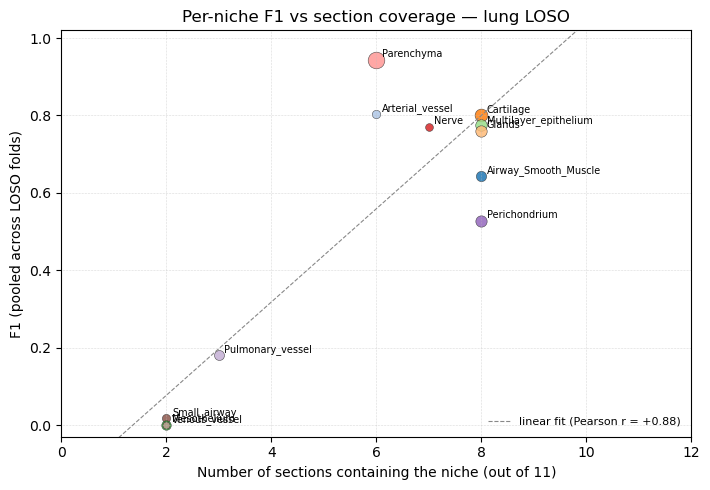

In [115]:
# Per-niche F1 vs section coverage
# x = how many of the 11 sections contain at least one spot of this label
# y = pooled F1 across LOSO folds (the per_label['f1'] from the previous cell)
# size = sqrt(GT spot count) — bigger dot = more support
import numpy as np

# 1. Section coverage per niche (constant — doesn't depend on fold).
coverage = (
    adata.obs.groupby("tissue_label")["section_ID"]
    .nunique()
    .rename("n_sections")
    .reset_index()
)

# 2. Merge with the F1 table built earlier (`per_label`).
merged = per_label.merge(coverage, on="tissue_label").rename(
    columns={"n_spots_gt": "support"}
)

# 3. Correlations.
r_pearson  = merged[["n_sections", "f1"]].corr().iloc[0, 1]
r_spearman = merged[["n_sections", "f1"]].corr(method="spearman").iloc[0, 1]
print(f"Pearson  r = {r_pearson:+.3f}  (n = {len(merged)} niches)")
print(f"Spearman r = {r_spearman:+.3f}")

# 4. Plot.
n_total_sections = adata.obs["section_ID"].nunique()
fig, ax = plt.subplots(figsize=(7.2, 5))

for _, r in merged.iterrows():
    ax.scatter(
        r["n_sections"], r["f1"],
        s=20 + 1.5 * (r["support"] ** 0.5),
        color=label_to_colour.get(r["tissue_label"], "#bbbbbb"),
        edgecolors="#333", linewidths=0.4, alpha=0.85,
    )
    ax.annotate(
        r["tissue_label"], (r["n_sections"], r["f1"]),
        xytext=(4, 2), textcoords="offset points", fontsize=7,
    )

# 5. Linear fit + Pearson annotation.
z  = np.polyfit(merged["n_sections"], merged["f1"], 1)
xs = np.linspace(0, n_total_sections + 1, 50)
ax.plot(xs, np.polyval(z, xs), "--", color="#888", linewidth=0.8,
        label=f"linear fit (Pearson r = {r_pearson:+.2f})")

ax.set_xlim(0, n_total_sections + 1)
ax.set_ylim(-0.03, 1.02)
ax.set_xlabel(f"Number of sections containing the niche (out of {n_total_sections})")
ax.set_ylabel("F1 (pooled across LOSO folds)")
ax.set_title("Per-niche F1 vs section coverage — lung LOSO")
ax.grid(linestyle=":", linewidth=0.4, color="#bbb")
ax.legend(loc="lower right", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(f'{figdir}/TissueTypist_Lung-VisiumSD_per-nichF1-vs-section-coverage.pdf', bbox_inches="tight",dpi=300)
plt.show()

## 8. Where are the errors?

A pooled confusion matrix, plus a side-by-side ground-truth vs
prediction map for one section. Helps spot whether errors are mostly
*confusions between adjacent niches* (often acceptable) or
*structurally wrong* (a real failure).


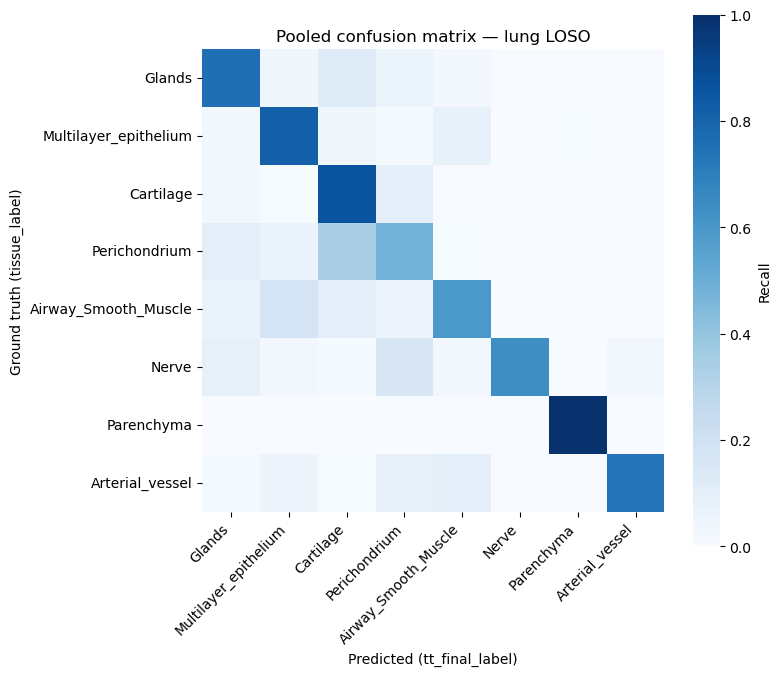

In [116]:
# keep only the niches which has more than 3 sections

from sklearn.metrics import confusion_matrix

cm_df = pd.crosstab(pooled["y_true"], pooled["y_pred"], normalize='index')

df = pooled[['section','y_true']].drop_duplicates()
val_counts = df['y_true'].value_counts()
label_order = list(val_counts.index[val_counts>3]) # ordering based on n_sections
cm_df = cm_df.loc[
    [x for x in label_order if x in pooled["y_true"].unique()],
    [x for x in label_order if x in pooled["y_pred"].unique()]
    ].copy()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_df, cmap="Blues", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "Recall"}, ax=ax)
ax.set_xlabel("Predicted (tt_final_label)")
ax.set_ylabel("Ground truth (tissue_label)")
ax.set_title("Pooled confusion matrix — lung LOSO")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f'{figdir}/TissueTypist_Lung-VisiumSD_confusionmatrix.pdf', bbox_inches="tight",dpi=300)
plt.show()

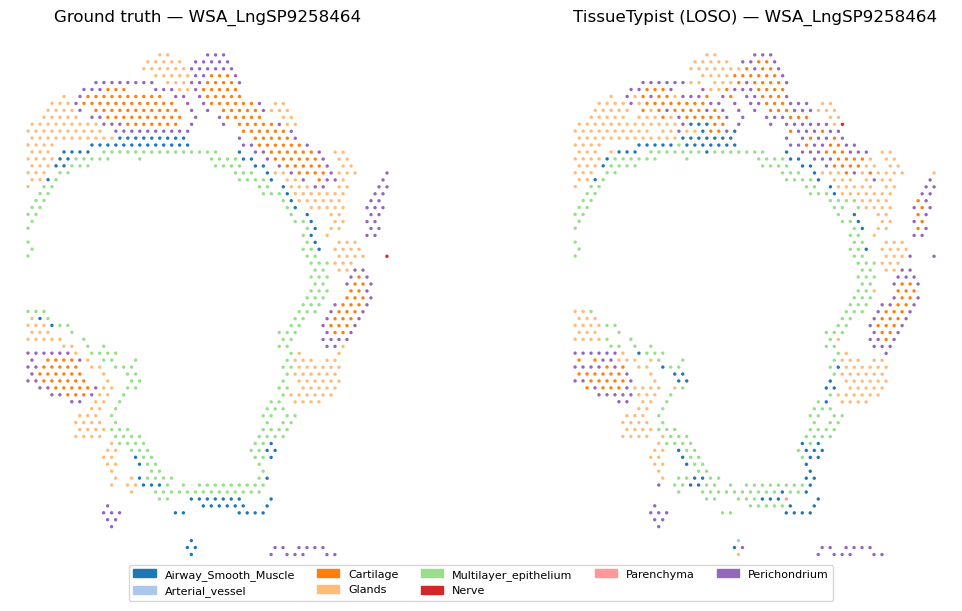

In [71]:
# Side-by-side: GT vs prediction for one held-out section.
sec = demo_section
a = sc.read_h5ad(LOSO_OUTDIR / "per_fold" / sec / "predicted.h5ad")
xy = a.obsm["spatial"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, col, title in [
    (axes[0], "tissue_label",   f"Ground truth — {sec}"),
    (axes[1], "tt_final_label", f"TissueTypist (LOSO) — {sec}"),
]:
    colours = [label_to_colour.get(l, "#cccccc") for l in a.obs[col].astype(str)]
    ax.scatter(xy[:, 0], xy[:, 1], c=colours, s=6, linewidths=0)
    ax.set_title(title)
    ax.set_aspect("equal"); ax.axis("off")
    ax.invert_yaxis()

# Single legend across both panels.
import matplotlib.patches as mpatches
present = sorted(set(a.obs["tissue_label"].astype(str))
                 | set(a.obs["tt_final_label"].astype(str)))
handles = [mpatches.Patch(color=label_to_colour.get(l, "#cccccc"), label=l)
           for l in present]
fig.legend(handles=handles, loc="lower center", ncol=min(5, len(present)),
           fontsize=8, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()
